# Find multiple edge projectors
Created 12/08/2026

Objectives:
* Iterate on [previous notebook](find_edge_projectors_initial_test.ipynb).
* Find multiple projectors.
* Update projector solver.

# Package imports

In [1]:
import sys

In [2]:
from itertools import chain, combinations
from collections import defaultdict
import re

In [3]:
import h5py
from tenpy.tools import hdf5_io
import tenpy
import tenpy.linalg.np_conserved as npc

import os
import pickle

In [65]:
import numpy as np
import jax.numpy as jnp

import pandas as pd

import matplotlib.pyplot as plt
import matplotlib

from scipy.optimize import minimize_scalar
from scipy.linalg import null_space

In [5]:
import quimb as qu
import quimb.tensor as qtn
from quimb.tensor.optimize import TNOptimizer
from quimb.tensor.tensor_core import tensor_direct_product

/Users/kierancooney/.pyenv/versions/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:54: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(
/Users/kierancooney/.pyenv/versions/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:36: UserWarning: Couldn't import `kahypar` - skipping from default hyper optimizer and using basic `labels` method instead.
  warnings.warn(
/Users/kierancooney/.pyenv/versions/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:73: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(


In [6]:
from quspin.operators import hamiltonian
from quspin.operators import quantum_operator
from quspin.basis import spin_basis_1d

In [7]:
from itertools import combinations

# Load data

In [8]:
L=20
basis = spin_basis_1d(L)

In [9]:
DATA_DIR = r"../../data/quspin_transverse_cluster_20_site"

In [10]:
energies = [
    np.load(rf'{DATA_DIR}/{i}.npz')['energy']
    for i in range(0, 101, 5)
]

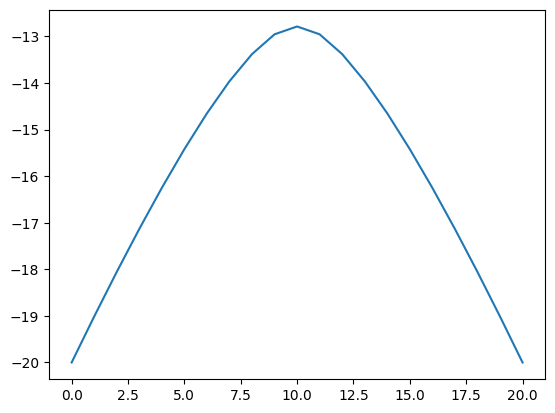

In [11]:
plt.plot(energies)

In [12]:
energies[0], energies[-1]

(array([-20.]), array([-20.]))

In [13]:
groundstates = [
    np.load(rf'{DATA_DIR}/{i}.npz')['psi']
    for i in range(0, 101, 5)
]

In [14]:
parameters = np.linspace(0, 1, 21)

In [15]:
parameters

array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ])

In [16]:
inds = [f'k{i}' for i in range(L)]

qt_groundstates = [
    qtn.Tensor(
        psi[::-1].reshape((2,)*L),
        inds=inds
    )
    for psi in groundstates
]

# Definitions

In [17]:
np_I = np.array([[1,0],[0,1]])
np_X = np.array([[0,1],[1,0]])

In [18]:
qu_I = qtn.Tensor(np_I, inds=['k', 'b'])
qu_X = qtn.Tensor(np_X, inds=['k', 'b'])

In [19]:
symmetry_actions = [
    [qu_I, qu_I],
    [qu_I, qu_X],
    [qu_X, qu_I],
    [qu_X, qu_X]
]

In [20]:
symmetry_labels = [
    'II',
    'IX',
    'XI',
    'XX'
]

In [21]:
def generate_edm(cut_psi, sites, symmetry_pair, num_defect_sites):
    assert 2*num_defect_sites < len(sites)

    left_defect_sites = sites[:num_defect_sites]
    right_defect_sites = sites[-num_defect_sites:]
    internal_sites = sites[num_defect_sites:-num_defect_sites]

    # Being sloppy with the gate indices as the symmetries are invariant
    # under transpose and conjugation.
    left_sym_gates = [
        symmetry_pair[i%2].reindex({'k': f'b{i}', 'b': f'c{i}'})
        for i in left_defect_sites
    ]

    inner_gates = [
        symmetry_pair[i%2].reindex({'k': f'k{i}', 'b': f'b{i}'})
        for i in internal_sites
    ]

    right_sym_gates = [
        symmetry_pair[i%2].reindex({'k': f'b{i}', 'b': f'c{i}'})
        for i in right_defect_sites
    ]

    psi_bra_reindex_map = (
        {f'k{i}': f'c{i}' for i in left_defect_sites + right_defect_sites}
        | {f'k{i}': f'b{i}' for i in internal_sites}
    )

    edm = (
        cut_psi
        & left_sym_gates
        & inner_gates
        & right_sym_gates
        & cut_psi.conj().reindex(psi_bra_reindex_map)
    )

    edm = edm.contract()

    fuse_maps = [
        ('k_left', (f'k{i}' for i in left_defect_sites)),
        ('b_left', (f'b{i}' for i in left_defect_sites)),
        ('k_right', (f'k{i}' for i in right_defect_sites)),
        ('b_right', (f'b{i}' for i in right_defect_sites))
    ]

    edm.fuse(fuse_maps, inplace=True)

    return edm

## Optimisation functions

In [22]:
def solve_for_boundary_operators(edm, num_iters=20):
    # Careful, the indices are reversed here for ease.
    # i.e. the k, b indices have been swapped to make tensor contraction easier.
    scores = list()

    u_left = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('b_left'), edm.ind_size('k_left')),
        inds=['k_left', 'b_left'],
        dtype='complex64'
    )

    u_right = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('b_right'), edm.ind_size('k_right')),
        inds=['k_right', 'b_right'],
        dtype='complex64'
    )

    for _ in range(num_iters):
        right_edm = (edm & u_left).contract()
        data = right_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        u_right = qtn.Tensor(sol, inds = ['b_right', 'k_right'])
        
        left_edm = (edm & u_right).contract()
        data = left_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        u_left = qtn.Tensor(sol, inds = ['b_left', 'k_left'])

    return (u_left, u_right), scores

## Find projectors

In [66]:
def numerical_radius(M, n_theta=200, refine=True):
    # Provided by Claude. No constraints.
    # The Coarse grid search may end up being a bit slow...
    n = M.shape[0]
    Mh = M.conj().T

    def lambda_max(theta):
        H = (np.exp(1j*theta)*M + np.exp(-1j*theta)*Mh) / 2  # Hermitian
        return np.linalg.eigvalsh(H)[-1]

    # coarse grid search
    thetas = np.linspace(0, 2*np.pi, n_theta, endpoint=False)
    vals = [lambda_max(t) for t in thetas]
    best_t = thetas[np.argmax(vals)]

    if refine:
        # polish with local optimization around the best grid point
        res = minimize_scalar(lambda t: -lambda_max(t),
                               bounds=(best_t - 2*np.pi/n_theta, best_t + 2*np.pi/n_theta),
                               method='bounded')
        best_t = res.x

    H = (np.exp(1j*best_t)*M + np.exp(-1j*best_t)*Mh) / 2
    w, v = np.linalg.eigh(H)
    x_opt = v[:, -1]              # eigenvector for largest eigenvalue
    r = w[-1]                      # = |x_opt^† M x_opt|
    return r, x_opt, best_t

In [24]:
# Example
np.random.seed(0)
n = 5
M = np.random.randn(n, n) + 1j*np.random.randn(n, n)

r, x_opt, theta = numerical_radius(M)
val = x_opt.conj() @ M @ x_opt
print("numerical radius r =", r)
print("|x^dagger M x|^2   =", abs(val)**2)     # this is your maximized quantity
print("check |val| == r   :", np.isclose(abs(val), r))

numerical radius r = 5.338716714381204
|x^dagger M x|^2   = 28.50189615645962
check |val| == r   : True


In [79]:
# Provided by Claude to handle case with orthogonal constraints

def orthogonal_complement_basis(Y, n=None, rtol=1e-10):
    """
    Y: (k, n) array of constraint rows, (n,) for a single constraint,
       or None / empty for no constraints.
    n: dimension, required if Y has no columns to infer it from.
    """
    if Y is None or np.size(Y) == 0:
        if n is None:
            raise ValueError("Must supply n when Y is empty.")
        return np.eye(n, dtype=complex)     # no constraints -> full space

    Y = np.atleast_2d(Y)
    if Y.shape[1] == 0:                      # e.g. Y = [] misparsed as (1,0)
        if n is None:
            raise ValueError("Must supply n when Y has no columns.")
        return np.eye(n, dtype=complex)

    V = null_space(Y.conj(), rcond=rtol)
    return V

def numerical_radius(M, n_theta=200, refine=True):
    n = M.shape[0]
    Mh = M.conj().T
    def lambda_max(theta):
        H = (np.exp(1j*theta)*M + np.exp(-1j*theta)*Mh) / 2
        return np.linalg.eigvalsh(H)[-1]
    thetas = np.linspace(0, 2*np.pi, n_theta, endpoint=False)
    vals = [lambda_max(t) for t in thetas]
    best_t = thetas[np.argmax(vals)]
    if refine:
        res = minimize_scalar(lambda t: -lambda_max(t),
                               bounds=(best_t - 2*np.pi/n_theta, best_t + 2*np.pi/n_theta),
                               method='bounded')
        best_t = res.x
    H = (np.exp(1j*best_t)*M + np.exp(-1j*best_t)*Mh) / 2
    w, v = np.linalg.eigh(H)
    return w[-1], v[:, -1], best_t

def constrained_max_multi(M, Y):
    n = M.shape[0]
    V = orthogonal_complement_basis(Y, n=n)
    if V.shape[1] == 0:
        raise ValueError("Constraints leave no feasible subspace.")
    M_proj = V.conj().T @ M @ V
    r, xp_opt, theta = numerical_radius(M_proj)
    x_opt = V @ xp_opt
    return r, x_opt

# --- example: n=6, 3 orthogonality constraints ---
np.random.seed(0)
n, k = 6, 3
M = np.random.randn(n, n) + 1j*np.random.randn(n, n)
Y = np.random.randn(k, n) + 1j*np.random.randn(k, n)   # rows y_1, y_2, y_3

r, x_opt = constrained_max_multi(M, Y)
val = x_opt.conj() @ M @ x_opt

print("max |x^H M x|^2 =", r**2)
print("||x||           =", np.linalg.norm(x_opt))
print("constraint check |<y_i|x>| for each i:")
for i in range(k):
    print(f"  i={i}: {abs(Y[i].conj() @ x_opt):.2e}")

max |x^H M x|^2 = 13.27874376372347
||x||           = 1.0
constraint check |<y_i|x>| for each i:
  i=0: 1.96e-16
  i=1: 8.50e-17
  i=2: 3.72e-16


In [25]:
def orthogonalize_numpy_vectors(v, other_vectors):
    # Return a (normalized) vector v which is orthogonalto the list of
    # other vectors
    # Assumes all are numpy vectors.

    for w in other_vectors:
        v = v - (np.dot(w.conj(), v)*w)

    v = v/np.linalg.norm(v)

    return v

In [26]:
def add_quimb_tensor_networks(t1, t2):
    assert set(t1.inds) == set(t2.inds), f'{t1.inds} != {t2.inds}'

    out = tensor_direct_product(t1, t2, sum_inds=t1.inds)

    return out

In [27]:
def orthogonalize_quimb_vectors(v, other_vectors):
    # Return a (normalized) vector v which is orthogonalto the list of
    # other vectors
    # Assumes all are quimb vectors.


    for w in other_vectors:
        overlap = (w.conj() & v).contract()
        v = add_quimb_tensor_networks(v, -1*overlap*w)

    norm = np.sqrt(np.abs((v & v.conj()).contract()))
    v = v/norm

    return v

In [28]:
def random_uniform_complex(shape):
    return np.random.uniform(size=shape) + 1j*np.random.uniform(size=shape)

In [29]:
test_states = [
    qtn.Tensor(
        data=random_uniform_complex((2,)*5),
        inds=[f'k{i}' for i in range(5)]
    )
    for _ in range(2)
]

test_states = [
    v/np.sqrt((v&v.conj()).contract())
    for v in test_states
]

for _ in range(10):
    test_orthogonal_out = orthogonalize_quimb_vectors(
        test_states[0],
        test_states[1:]
    )

    test_states = [test_orthogonal_out, *test_states[1:]]

    v = qtn.Tensor(
        data=random_uniform_complex((2,)*5),
        inds=[f'k{i}' for i in range(5)]
    )

    v = v/np.sqrt((v&v.conj()).contract())

    test_states = [v, *test_states]

In [30]:
len(test_states)

12

In [31]:
v = test_states[1]

In [32]:
np.round(np.array([
    (v & w.conj()).contract()
    for w in test_states[2:]
]), 3)

array([-0.+0.j,  0.+0.j, -0.+0.j, -0.+0.j, -0.+0.j, -0.+0.j, -0.-0.j,
       -0.+0.j,  0.-0.j,  0.-0.j])

It works!

In [33]:
test_orthogonal_out

Tensor(shape=(2, 2, 2, 2, 2), inds=('k0', 'k1', 'k2', 'k3', 'k4'), tags=oset([]))

In [150]:
def maximize_single_projector_state(rho, left_rho_sites, right_rho_sites,
    prev_states=[], num_iters=20):
    scores = list()

    left_k_inds = [f'k{i}' for i in left_rho_sites]
    left_b_inds = [f'b{i}' for i in left_rho_sites]
    right_k_inds = [f'k{i}' for i in right_rho_sites]
    right_b_inds = [f'b{i}' for i in right_rho_sites]

    fused_rho = rho.fuse({
        'kl': left_k_inds,
        'kr': right_k_inds,
        'bl': left_b_inds,
        'br': right_b_inds
    })

    left_state = qtn.Tensor(
        data=random_uniform_complex((2**len(left_rho_sites),)),
        inds=['kl',]
    )

    if len(prev_states) > 0:
        prev_left_states, prev_right_states = zip(*prev_states)
    else:
        prev_left_states = []
        prev_right_states = []

    fused_prev_left_states = [
        s.fuse({'kl': left_k_inds})
        for s in prev_left_states
    ]

    fused_prev_right_states = [
        s.fuse({'kl': right_k_inds})
        for s in prev_right_states
    ]

    left_state = orthogonalize_quimb_vectors(
        left_state,
        fused_prev_left_states
    )

    np_prev_left_states = np.array([s.data for s in fused_prev_left_states])
    np_prev_right_states = np.array([s.data for s in fused_prev_right_states])

    for i in range(num_iters):
        right_matrix = (
            fused_rho
            & left_state.conj()
            & left_state.reindex({'kl': 'bl'})
        ).contract()
        data = (
            right_matrix
            .transpose('kr', 'br')
            .data
        )

        score, state_data = constrained_max_multi(
            data, np_prev_right_states
        )

        right_state = qtn.Tensor(
            data=state_data,
            inds=['kr',]
        )
        scores.append(score)

        left_matrix = (
            fused_rho
            & right_state.conj()
            & right_state.reindex({'kr': 'br'})
        ).contract()
        data = (
            left_matrix
            .transpose('kl', 'bl')
            .data
        )

        score, state_data = constrained_max_multi(
            data, np_prev_left_states
        )

        left_state = qtn.Tensor(
            data=state_data,
            inds=['kl',]
        )
        scores.append(score)

    left_state.unfuse(
        {'kl': left_k_inds},
        shape_map={'kl': (2,)*len(left_k_inds)},
        inplace=True
    )
    right_state.unfuse(
        {'kr': right_k_inds},
        shape_map={'kr': (2,)*len(right_k_inds)},
        inplace=True
    )

    return scores, (left_state, right_state)

In [37]:
def maximize_multiple_projector_states(rho, left_rho_sites, right_rho_sites,
    num_states, num_iters=20):

    prev_states = list()
    out = list()

    for i in range(num_states):
        current_out = maximize_single_projector_state(
            rho,
            left_rho_sites,
            right_rho_sites,
            prev_states,
            num_iters=num_iters
        )

        prev_states.append(current_out[1])
        out.append(current_out)

    return out

## Test that projecting out state from matrix results in an orthogonal output

In [111]:
n = 16
M = np.random.randn(n, n) + 1j*np.random.randn(n, n)
v = np.random.randn(n) + 1j*np.random.randn(n)
v = v/np.linalg.norm(v)

np.linalg.norm(v)
r, x_opt = constrained_max_multi(M, v)
print(np.abs(np.vdot(x_opt, v)))

8.886119947416683e-17


In [112]:
np.linalg.norm(v)

1.0

In [113]:
r, x_opt = constrained_max_multi(M, v)

# Test

In [170]:
left_rho_sites = list(range(8, 10))
right_rho_sites = list(range(10, 12))

rho_sites = left_rho_sites + right_rho_sites

In [171]:
psi = qt_groundstates[-1]
rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in rho_sites})).contract()

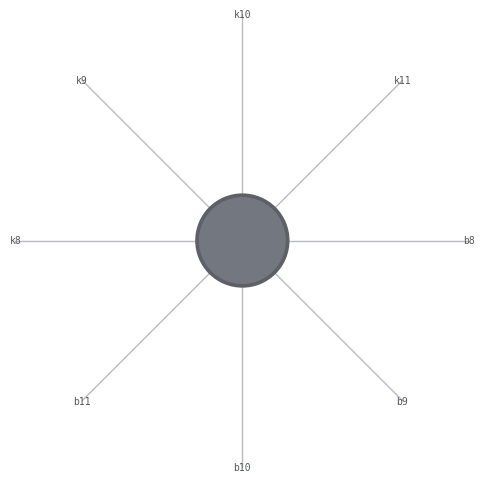

In [172]:
rho.draw()

In [173]:
left_state = qtn.Tensor(
    data=random_uniform_complex((2,)*len(left_rho_sites)),
    inds=[f'k{i}' for i in left_rho_sites]
)

right_state = qtn.Tensor(
    data=random_uniform_complex((2,)*len(right_rho_sites)),
    inds=[f'k{i}' for i in right_rho_sites]
)

In [174]:
(
    rho
    & left_state
    & right_state
    & left_state.conj().reindex({f'k{i}': f'b{i}' for i in left_rho_sites})
    & right_state.conj().reindex({f'k{i}': f'b{i}' for i in right_rho_sites})
).contract()

(0.5313884815177308+1.5612511283791264e-17j)

In [175]:
test_out = maximize_multiple_projector_states(
    rho,
    left_rho_sites,
    right_rho_sites,
    4,
    num_iters=20
)

In [176]:
len(test_out)

4

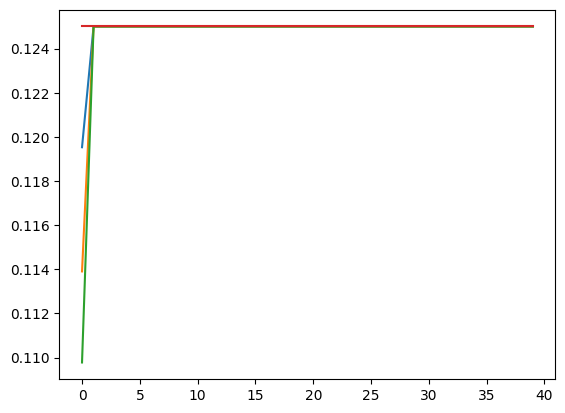

In [178]:
plt.plot(test_out[0][0])
plt.plot(test_out[1][0])
plt.plot(test_out[2][0])
plt.plot(test_out[3][0])

In [190]:
[np.round(l[1][0].data, 3) for l in test_out]

[array([[-0.55+0.j   , -0.15-0.362j],
        [ 0.6 -0.041j, -0.19-0.383j]]),
 array([[ 0.088-0.584j, -0.441-0.036j],
        [ 0.044-0.539j,  0.404+0.005j]]),
 array([[ 0.384+0.077j, -0.107-0.539j],
        [-0.424-0.055j, -0.156-0.58j ]]),
 array([[-0.048+0.44j , -0.59 -0.024j],
        [-0.016+0.404j,  0.54 -0.015j]])]

I am quite confused by this... Should manually check the Scmidt values.

In [179]:
[l[0][-1] for l in test_out]

[0.12499999999999975,
 0.12499999999999883,
 0.12499999999999964,
 0.12499999999999871]

Compute overlaps.

In [180]:
test_out[0][1][0]

Tensor(shape=(2, 2), inds=('k8', 'k9'), tags=oset([]))

In [181]:
[l[1][0] for l in test_out]

[Tensor(shape=(2, 2), inds=('k8', 'k9'), tags=oset([])),
 Tensor(shape=(2, 2), inds=('k8', 'k9'), tags=oset([])),
 Tensor(shape=(2, 2), inds=('k8', 'k9'), tags=oset([])),
 Tensor(shape=(2, 2), inds=('k8', 'k9'), tags=oset([]))]

In [182]:
left_overlaps = list()

for l in test_out:
    op = l[1][0]
    overlap = (op.conj() & op).contract()
    left_overlaps.append(overlap)

In [183]:
left_overlaps

[(1.0000000000000002+1.3877787807814457e-17j),
 (0.9999999999999993-8.673617379884035e-19j),
 (1.0000000000000002+0j),
 (1+1.734723475976807e-18j)]

In [184]:
right_overlaps = list()

for l in test_out:
    op = l[1][1]
    overlap = (op.conj() & op).contract()
    right_overlaps.append(overlap)

In [185]:
right_overlaps

[(1.0000000000000002-1.734723475976807e-18j),
 (1-1.734723475976807e-18j),
 (0.9999999999999999+7.806255641895632e-18j),
 (1.0000000000000002+3.469446951953614e-18j)]

In [186]:
left_overlaps = list()

for l1, l2 in combinations(test_out, 2):
    op1 = l1[1][0]
    op2 = l2[1][0]
    overlap = (op1.conj() & op2).contract()
    left_overlaps.append(overlap)

In [187]:
np.round(np.array(left_overlaps), 3)

array([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.-0.j, 0.-0.j])

In [168]:
right_overlaps = list()

for l1, l2 in combinations(test_out, 2):
    op1 = l1[1][1]
    op2 = l2[1][1]
    overlap = (op1.conj() & op2).contract()
    right_overlaps.append(overlap)

In [169]:
np.round(np.array(right_overlaps), 3)

array([0.+0.j])

In [138]:
num_states=2
num_iters=20

In [139]:
prev_states = list()
out = list()

In [140]:
current_out = maximize_single_projector_state(
    rho,
    left_rho_sites,
    right_rho_sites,
    prev_states,
    num_iters=num_iters
)

In [144]:
left_state_0 = current_out[1][0]
right_state_0 = current_out[1][1]

In [145]:
(left_state_0 & left_state_0.conj()).contract()

(0.9999999999999999-1.3877787807814457e-17j)

In [146]:
(right_state_0 & right_state_0.conj()).contract()

(0.9999999999999997+0j)

Ok, so the first pass is working. Onto second pass.

In [147]:
prev_states.append(current_out[1])

In [149]:
(
    left_rho_sites,
    right_rho_sites
)

([8, 9], [10, 11])

Ok, a bit better.

In [236]:
test_scores = test_out[0]

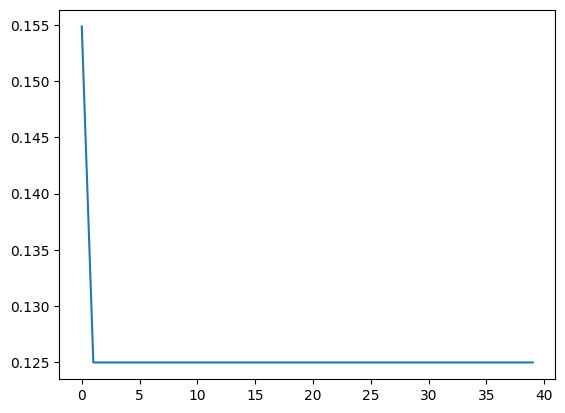

In [40]:
plt.plot(test_scores)

In [44]:
left_state

Tensor(shape=(2, 2), inds=('k8', 'k9'), tags=oset([]))

In [41]:
test_scores

[0.15485382943015732,
 0.12499999999999983,
 0.12499999999999983,
 0.12499999999999989,
 0.12499999999999986,
 0.12499999999999994,
 0.12499999999999988,
 0.12499999999999994,
 0.12499999999999983,
 0.12499999999999986,
 0.12499999999999988,
 0.12499999999999979,
 0.12499999999999986,
 0.12499999999999989,
 0.12499999999999994,
 0.12499999999999989,
 0.12499999999999982,
 0.12499999999999992,
 0.12499999999999988,
 0.12499999999999989,
 0.12499999999999989,
 0.12499999999999992,
 0.12499999999999989,
 0.1249999999999998,
 0.12499999999999988,
 0.12499999999999986,
 0.12499999999999983,
 0.125,
 0.12499999999999985,
 0.12499999999999997,
 0.12499999999999985,
 0.12499999999999992,
 0.12499999999999989,
 0.12499999999999986,
 0.12499999999999978,
 0.12499999999999989,
 0.12499999999999989,
 0.12499999999999986,
 0.12499999999999986,
 0.12499999999999978]

Ok, so it appears to work.

In [35]:
left_rho_sites = list(range(4, 6))
right_rho_sites = list(range(6, 8))

rho_sites = left_rho_sites + right_rho_sites

In [36]:
left_rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in rho_sites})).contract()

In [37]:
help(left_rho.unfuse)

Help on method unfuse in module quimb.tensor.tensor_core:

unfuse(unfuse_map, shape_map, inplace=False) method of quimb.tensor.tensor_core.Tensor instance
    Reshape single indices into groups of multiple indices
    
    Parameters
    ----------
    unfuse_map : dict_like or sequence of tuples.
        Mapping like: ``{existing_ind: sequence of new inds, ...}`` or an
        ordered mapping like ``[(old_ind_1, new_inds_1), ...]`` in which
        case the output tensor's new inds will be ordered. In both cases
        the new indices are created at the old index's position of the
        tensor's shape
    shape_map : dict_like or sequence of tuples
        Mapping like: ``{old_ind: new_ind_sizes, ...}`` or an
        ordered mapping like ``[(old_ind_1, new_ind_sizes_1), ...]``.
    
    Returns
    -------
    Tensor
        The transposed, reshaped and re-labeled tensor



In [38]:
left_test_out = maximize_projector_states(
    left_rho,
    left_rho_sites,
    right_rho_sites,
    num_iters=20
)

In [39]:
left_rho_sites = list(range(12, 14))
right_rho_sites = list(range(14, 16))

rho_sites = left_rho_sites + right_rho_sites

In [40]:
right_rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in rho_sites})).contract()

In [41]:
right_test_out = maximize_projector_states(
    right_rho,
    left_rho_sites,
    right_rho_sites,
    num_iters=20
)

In [42]:
right_test_out[0]

[0.2875563595440911,
 0.12499999999999976,
 0.12499999999999975,
 0.12499999999999986,
 0.12499999999999975,
 0.12499999999999967,
 0.12499999999999974,
 0.12499999999999975,
 0.12499999999999976,
 0.12499999999999967,
 0.12499999999999975,
 0.12499999999999964,
 0.12499999999999983,
 0.12499999999999965,
 0.12499999999999978,
 0.12499999999999971,
 0.12499999999999982,
 0.12499999999999976,
 0.12499999999999968,
 0.12499999999999985,
 0.12499999999999974,
 0.12499999999999974,
 0.12499999999999975,
 0.12499999999999972,
 0.1249999999999998,
 0.12499999999999983,
 0.1249999999999997,
 0.1249999999999999,
 0.12499999999999978,
 0.1249999999999998,
 0.12499999999999967,
 0.12499999999999985,
 0.12499999999999971,
 0.12499999999999986,
 0.12499999999999972,
 0.12499999999999972,
 0.12499999999999976,
 0.12499999999999976,
 0.1249999999999998,
 0.12499999999999983]

In [43]:
left_test_out[0]

[0.31683846338704247,
 0.12499999999999967,
 0.12499999999999956,
 0.12499999999999951,
 0.12499999999999958,
 0.1249999999999996,
 0.12499999999999971,
 0.12499999999999964,
 0.12499999999999965,
 0.12499999999999965,
 0.12499999999999964,
 0.12499999999999967,
 0.12499999999999963,
 0.12499999999999967,
 0.12499999999999964,
 0.12499999999999971,
 0.12499999999999963,
 0.12499999999999968,
 0.12499999999999972,
 0.12499999999999961,
 0.12499999999999958,
 0.12499999999999957,
 0.12499999999999968,
 0.12499999999999957,
 0.12499999999999975,
 0.12499999999999972,
 0.12499999999999967,
 0.12499999999999972,
 0.12499999999999954,
 0.12499999999999957,
 0.12499999999999961,
 0.12499999999999968,
 0.12499999999999965,
 0.12499999999999951,
 0.12499999999999971,
 0.12499999999999961,
 0.12499999999999967,
 0.12499999999999967,
 0.12499999999999958,
 0.12499999999999965]

In [44]:
left_test_out[1]

(Tensor(shape=(2, 2), inds=('k4', 'k5'), tags=oset([])),
 Tensor(shape=(2, 2), inds=('k6', 'k7'), tags=oset([])))

In [45]:
left_proj_state = left_test_out[1][1]
right_proj_state = right_test_out[1][0]

In [46]:
np.round(left_proj_state.data, 3)

array([[ 0.156-0.189j, -0.353+0.531j],
       [ 0.26 +0.027j,  0.681+0.j   ]])

In [47]:
np.round(right_proj_state.data, 3)

array([[ 0.743+0.j   ,  0.181-0.002j],
       [ 0.622+0.069j, -0.151-0.015j]])

In [48]:
np.round(left_test_out[1][0].data, 3)

array([[ 0.768+0.j   , -0.032+0.411j],
       [ 0.431+0.019j,  0.028-0.23j ]])

In [49]:
np.round(right_test_out[1][1].data, 3)

array([[ 0.853+0.j   ,  0.03 +0.012j],
       [ 0.52 -0.002j, -0.018-0.007j]])

In [50]:
psi

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2), inds=('k0', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6', 'k7', 'k8', 'k9', 'k10', 'k11', 'k12', 'k13', 'k14', 'k15', 'k16', 'k17', 'k18', 'k19'), tags=oset([]))

In [51]:
left_proj_state

Tensor(shape=(2, 2), inds=('k6', 'k7'), tags=oset([]))

In [52]:
right_proj_state

Tensor(shape=(2, 2), inds=('k12', 'k13'), tags=oset([]))

In [53]:
proj_psi = (
    psi.reindex({'k6': 'b6', 'k7': 'b7', 'k12': 'b12', 'k13': 'b13'})
    & left_proj_state.conj().reindex({'k6': 'b6', 'k7': 'b7'})
    & left_proj_state
    & right_proj_state.conj().reindex({'k12': 'b12', 'k13': 'b13'})
    & right_proj_state
)

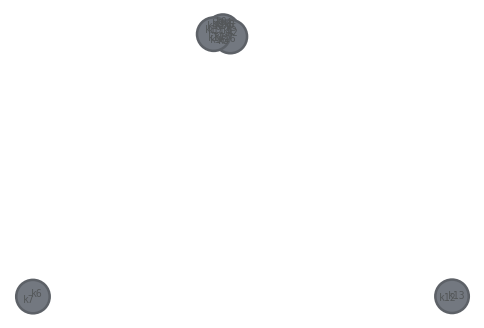

In [54]:
proj_psi.draw()

In [55]:
proj_psi.contract(inplace=True)

TensorNetwork(tensors=1, indices=20)

In [56]:
norm = (
    proj_psi
    & proj_psi.conj()
).contract()

In [57]:
proj_psi = np.power(norm, -0.5)*proj_psi

In [58]:
norm = (
    proj_psi
    & proj_psi.conj()
).contract()

In [59]:
norm

(0.9999999999997667+0j)

Check Schmidt decomposition

In [60]:
proj_psi

TensorNetwork(tensors=1, indices=20)

In [61]:
schmidt_decomp = qtn.tensor_core.tensor_split(
    proj_psi.tensors[0],
    left_inds=[f'k{i}' for i in range(6, 14)],
    method='svd',
    #cutoff=1e-6,
    cutoff_mode='abs',
    absorb=None,
    renorm=True,
    bond_ind='vLV'
)

In [62]:
schmidt_decomp.tensors[1].data

array([1.])

In [63]:
schmidt_decomp = qtn.tensor_core.tensor_split(
    psi,
    left_inds=[f'k{i}' for i in range(6, 14)],
    method='svd',
    #cutoff=1e-6,
    cutoff_mode='abs',
    absorb=None,
    renorm=True,
    bond_ind='vLV'
)

In [64]:
schmidt_decomp.tensors[1].data

array([0.5, 0.5, 0.5, 0.5])

Nice, clean cut.

In [65]:
schmidt_decomp

TensorNetwork(tensors=3, indices=21)

In [66]:
cut_psi = schmidt_decomp.tensors[0]

In [67]:
cut_psi = cut_psi.isel({'vLV':0})

In [68]:
cut_psi

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2), inds=('k6', 'k7', 'k8', 'k9', 'k10', 'k11', 'k12', 'k13'), tags=oset([]))

In [69]:
sites = list(range(6, 14))

In [70]:
edm = generate_edm(cut_psi, sites, symmetry_actions[1], 3)

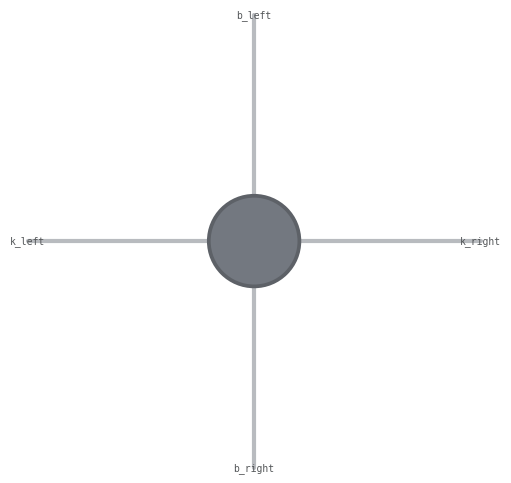

In [71]:
edm.draw()

In [72]:
edm.ind_size('k_left')

8

In [73]:
defect_ops_out = solve_for_boundary_operators(edm, num_iters=20)

In [74]:
defect_ops_out[1]

[1.4824081511429659,
 1.0,
 1.0000000000000004,
 1.0,
 1.0000000000000004,
 1.0000000000000004,
 1.0000000000000002,
 1.0000000000000007,
 1.0000000000000004,
 1.0000000000000004,
 1.0000000000000004,
 1.0000000000000002,
 1.0000000000000002,
 1.0000000000000004,
 1.0000000000000004,
 1.0000000000000007,
 1.0000000000000004,
 1.0000000000000007,
 1.0,
 1.0000000000000004,
 1.0000000000000004,
 1.0000000000000004,
 1.0000000000000002,
 1.0000000000000002,
 1.0000000000000004,
 1.0000000000000004,
 1.0000000000000002,
 1.0000000000000004,
 1.0,
 1.0000000000000004,
 1.0000000000000002,
 1.0,
 1.0,
 1.0000000000000004,
 1.0000000000000002,
 1.0000000000000002,
 1.0000000000000004,
 1.0000000000000004,
 0.9999999999999998,
 1.0]

Needed 3 site defect operators, for some reason...

In [75]:
edms = [
    generate_edm(cut_psi, sites, s, 3)
    for s in symmetry_actions[1:]
]

In [76]:
defect_ops_results = [
    solve_for_boundary_operators(edm, num_iters=20)
    for edm in edms
]

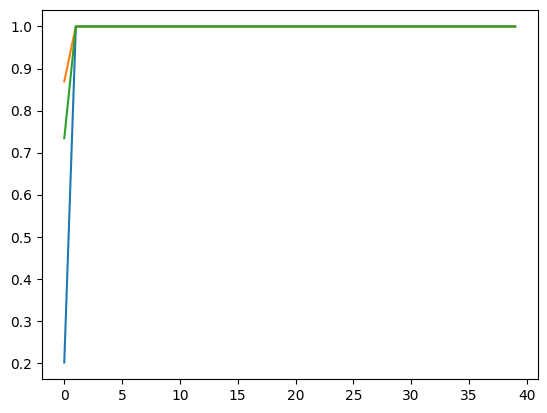

In [77]:
for l in defect_ops_results:
    plt.plot(l[1])

In [78]:
[l[1][-1] for l in defect_ops_results]

[1.0000000000000004, 1.0000000000000004, 1.0000000000000004]

Looks good! Now calculate the invariants.

## SPT extraction functions

In [79]:
symmetry_combination_labels = list(combinations(symmetry_labels, 2))

In [80]:
symmetry_combination_labels

[('II', 'IX'),
 ('II', 'XI'),
 ('II', 'XX'),
 ('IX', 'XI'),
 ('IX', 'XX'),
 ('XI', 'XX')]

In [81]:
e, a, b, c = symmetry_labels

In [82]:
group_products = [
    (a, b, c),
    (b, a, c),
    (a, c, b),
    (c, a, b),
    (c, b, a),
    (b, c, a)
]

In [83]:
defect_ops_results[0][0][1]

Tensor(shape=(8, 8), inds=('b_right', 'k_right'), tags=oset([]))

In [84]:
def get_proj_rep_phase(cut_rho, r_g, r_h, r_gh, u_g, left_right):
    k_ind = f'k_{left_right}'
    b_ind = f'b_{left_right}'

    invariant_tn = (
        cut_rho
        & r_g.reindex({b_ind: 'i1'})
        & u_g.conj().reindex({k_ind: 'i1', b_ind: 'i2'})
        & r_h.reindex({k_ind: 'i2', b_ind: 'i3'})
        & u_g.reindex({b_ind: 'i3', k_ind: 'i4'})
        & r_gh.conj().reindex({b_ind: 'i4', k_ind: b_ind})
    )

    out = invariant_tn.contract()

    return out

In [85]:
symmetry_labels

['II', 'IX', 'XI', 'XX']

In [86]:
def get_defect_symmetry_gate(symmetry_label, defect_sites, left_right):
    sym_pair = next(
        pair for label, pair in zip(symmetry_labels, symmetry_actions)
    )

    sym_gates = [
        sym_pair[i%2].reindex({'k': f'k{i}', 'b': f'b{i}'})
        for i in defect_sites
    ]

    fuse_map = [
        (f'k_{left_right}', (f'k{i}' for i in defect_sites)),
        (f'b_{left_right}', (f'b{i}' for i in defect_sites))
    ]
   
    gate = (
        qtn
        .TensorNetwork(sym_gates)
        .contract()
        .fuse(fuse_map)
    )

    return gate

In [87]:
def get_proj_rep_phases(rho, unitaries, left_right, defect_sites):
    out = list()

    unitaries_dict = {
        k: v for k, v in zip(symmetry_labels[1:], unitaries)
    }

    out_phases = list()
    for a, b, c in group_products:
        sym_gate = get_defect_symmetry_gate(
            a, defect_sites, left_right
        )

        phase = get_proj_rep_phase(
            rho,
            unitaries_dict[a],
            unitaries_dict[b],
            unitaries_dict[c],
            sym_gate,
            left_right
        )

        out_phases.append(phase)

    return out_phases

In [88]:
cut_psi

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2), inds=('k6', 'k7', 'k8', 'k9', 'k10', 'k11', 'k12', 'k13'), tags=oset([]))

In [89]:
left_defect_sites = [6, 7, 8]
right_defect_sites = [11, 12, 13]

In [90]:
left_rdm = (
    cut_psi
    & cut_psi.conj().reindex({f'k{i}': f'b{i}' for i in left_defect_sites})
)
left_rdm = left_rdm.contract()
fuse_map = [
    ('k_left', (f'k{i}' for i in left_defect_sites)),
    ('b_left', (f'b{i}' for i in left_defect_sites))
]
left_rdm.fuse(fuse_map, inplace=True)

right_rdm = (
    cut_psi
    & cut_psi.conj().reindex({f'k{i}': f'b{i}' for i in right_defect_sites})
)
right_rdm = right_rdm.contract()
fuse_map = [
    ('k_right', (f'k{i}' for i in right_defect_sites)),
    ('b_right', (f'b{i}' for i in right_defect_sites))
]
right_rdm.fuse(fuse_map, inplace=True)

Tensor(shape=(8, 8), inds=('k_right', 'b_right'), tags=oset([]))

In [91]:
left_rdm

Tensor(shape=(8, 8), inds=('k_left', 'b_left'), tags=oset([]))

In [92]:
cut_psi

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2), inds=('k6', 'k7', 'k8', 'k9', 'k10', 'k11', 'k12', 'k13'), tags=oset([]))

In [93]:
left_rdm

Tensor(shape=(8, 8), inds=('k_left', 'b_left'), tags=oset([]))

In [94]:
right_rdm

Tensor(shape=(8, 8), inds=('k_right', 'b_right'), tags=oset([]))

In [95]:
unitary_pairs = [l[0] for l in defect_ops_results]
left_unitaries, right_unitaries = zip(*unitary_pairs)

In [96]:
left_phases = np.array(get_proj_rep_phases(left_rdm, left_unitaries, 'left', left_defect_sites))

In [97]:
left_phases

array([ 0.97353629-0.22853247j, -0.45951144-0.88229616j,
       -0.2304446 +0.97308545j,  0.99464037-0.01696485j,
        0.00264097-0.04934006j, -0.176924  +0.61836779j])

In [98]:
left_phases[::2]/left_phases[1::2]

array([-0.24830075+0.97409384j, -0.24830075+0.97409384j,
       -0.07488274+0.01715417j])

Invariants are totally wrong, shoot.

## Manual projectors, $\ket{0}\bra{0}_Z$

In [124]:
left_proj_state = qtn.Tensor(data=[1,0], inds=['k6'])
right_proj_state = qtn.Tensor(data=[1,0], inds=['k13'])

In [125]:
proj_psi = (
    psi.reindex({'k6': 'b6', 'k13': 'b13'})
    & left_proj_state.conj().reindex({'k6': 'b6'})
    & left_proj_state
    & right_proj_state.conj().reindex({'k13': 'b13'})
    & right_proj_state
)

In [126]:
proj_psi.contract(inplace=True)

TensorNetwork(tensors=1, indices=20)

In [127]:
norm = (
    proj_psi
    & proj_psi.conj()
).contract()

In [128]:
norm

(0.24999999999999983+3.5711569487385687e-20j)

In [129]:
proj_psi = np.power(norm, -0.5)*proj_psi

In [130]:
norm = (
    proj_psi
    & proj_psi.conj()
).contract()

In [131]:
norm

(0.9999999999999993+1.4288324372531337e-19j)

Check Schmidt decomposition

In [132]:
proj_psi

TensorNetwork(tensors=1, indices=20)

In [133]:
schmidt_decomp = qtn.tensor_core.tensor_split(
    proj_psi.tensors[0],
    left_inds=[f'k{i}' for i in range(6, 14)],
    method='svd',
    #cutoff=1e-6,
    cutoff_mode='abs',
    absorb=None,
    renorm=True,
    bond_ind='vLV'
)

In [134]:
schmidt_decomp.tensors[1].data

array([1.])

In [135]:
cut_psi = schmidt_decomp.tensors[0]

In [136]:
cut_psi = cut_psi.isel({'vLV':0})

In [137]:
cut_psi

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2), inds=('k6', 'k7', 'k8', 'k9', 'k10', 'k11', 'k12', 'k13'), tags=oset([]))

In [138]:
sites = list(range(6, 14))

In [139]:
edm = generate_edm(cut_psi, sites, symmetry_actions[1], 2)

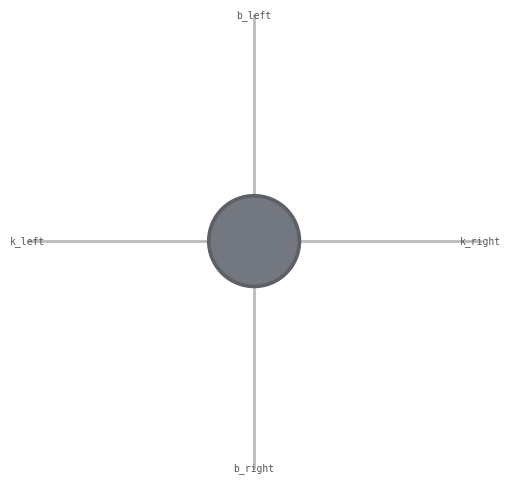

In [140]:
edm.draw()

In [141]:
edms = [
    generate_edm(cut_psi, sites, s, 2)
    for s in symmetry_actions[1:]
]

In [142]:
defect_ops_results = [
    solve_for_boundary_operators(edm, num_iters=20)
    for edm in edms
]

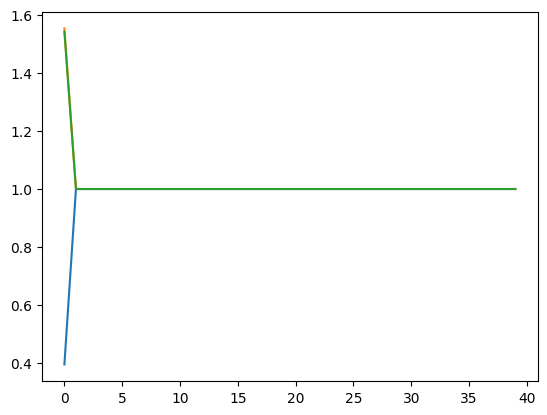

In [143]:
for l in defect_ops_results:
    plt.plot(l[1])

In [144]:
left_defect_sites = [6, 7]
right_defect_sites = [12, 13]

In [145]:
left_rdm = (
    cut_psi
    & cut_psi.conj().reindex({f'k{i}': f'b{i}' for i in left_defect_sites})
)
left_rdm = left_rdm.contract()
fuse_map = [
    ('k_left', (f'k{i}' for i in left_defect_sites)),
    ('b_left', (f'b{i}' for i in left_defect_sites))
]
left_rdm.fuse(fuse_map, inplace=True)

right_rdm = (
    cut_psi
    & cut_psi.conj().reindex({f'k{i}': f'b{i}' for i in right_defect_sites})
)
right_rdm = right_rdm.contract()
fuse_map = [
    ('k_right', (f'k{i}' for i in right_defect_sites)),
    ('b_right', (f'b{i}' for i in right_defect_sites))
]
right_rdm.fuse(fuse_map, inplace=True)

Tensor(shape=(4, 4), inds=('k_right', 'b_right'), tags=oset([]))

In [146]:
unitary_pairs = [l[0] for l in defect_ops_results]
left_unitaries, right_unitaries = zip(*unitary_pairs)

In [147]:
left_phases = np.array(get_proj_rep_phases(left_rdm, left_unitaries, 'left', left_defect_sites))

In [148]:
left_phases

array([ 0.72355768-0.69026393j,  0.98735284+0.15853823j,
        0.47108694-0.88208679j,  0.98735284-0.15853823j,
       -0.68785949+0.72103726j, -0.71636378-0.02741016j])

In [149]:
left_phases[::2]/left_phases[1::2]

array([0.6049735 -0.7962456j , 0.6049735 -0.7962456j ,
       0.92034979-1.04173916j])

In [150]:
right_phases = np.array(get_proj_rep_phases(
    right_rdm,
    right_unitaries,
    'right',
    right_defect_sites
))

In [151]:
right_phases

array([-4.78065154e-03-3.90190630e-03j, -7.23557676e-01-6.90263927e-01j,
       -3.05464269e-15+1.28102020e-15j,  3.14489253e-15+1.83241190e-15j,
        4.82844276e-03-3.84260880e-03j,  8.28220534e-01-5.60402308e-01j])

In [152]:
right_phases[::2]/right_phases[1::2]

array([ 0.00615242-4.76657049e-04j, -0.54794091+7.26598325e-01j,
        0.00615242-4.76657049e-04j])

In [159]:
np.round(
    left_unitaries[0]
    .unfuse(
        {'k_left': ['k1', 'k2'], 'b_left': ['b1', 'b2']},
        shape_map = {'k_left': (2,2), 'b_left': (2,2)}
    ) 
    .transpose('k1', 'b1', 'k2', 'b2')
    .data,
    3
)

array([[[[ 0.605-0.796j,  0.   -0.j   ],
         [-0.   +0.j   ,  0.605-0.796j]],

        [[ 0.   -0.j   ,  0.   -0.j   ],
         [ 0.   -0.j   ,  0.   -0.j   ]]],


       [[[ 0.   -0.j   ,  0.   -0.j   ],
         [ 0.   -0.j   ,  0.   -0.j   ]],

        [[ 1.   -0.j   ,  0.   -0.j   ],
         [ 0.   -0.j   ,  1.   -0.j   ]]]])

In [161]:
def split_defect_op(defect_op, left_right):
    unfused_defect_op = (
        defect_op
        .unfuse(
            {'k_left': ['k1', 'k2'], 'b_left': ['b1', 'b2']},
            shape_map = {f'k_{left_right}': (2,2), f'b_{left_right}': (2,2)}
        )
    )

    schmidt_decomp = qtn.tensor_core.tensor_split(
        unfused_defect_op,
        left_inds=['k1', 'k2'],
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='v'
    )

    return schmidt_decomp

In [163]:
U, s, V = split_defect_op(
    left_unitaries[0],
    'left'
)

In [164]:
s

Tensor(shape=(4,), inds=('v',), tags=oset([]))

Oh, it's entangled.

In [ ]:
qtn.tensor_core.tensor_split(
    proj_psi.tensors[0],
    left_inds=[f'k{i}' for i in range(6, 14)],
    method='svd',
    #cutoff=1e-6,
    cutoff_mode='abs',
    absorb=None,
    renorm=True,
    bond_ind='vLV'
)

In [156]:
np.round(left_unitaries[1].transpose('k_left', 'b_left').data, 3)

array([[ 0.   -0.j   ,  0.   -0.j   ,  0.083+0.997j,  0.   -0.j   ],
       [ 0.   -0.j   ,  0.   +0.j   , -0.   -0.j   , -0.083-0.997j],
       [ 1.   -0.j   ,  0.   -0.j   ,  0.   -0.j   ,  0.   -0.j   ],
       [ 0.   -0.j   , -0.986-0.166j,  0.   -0.j   , -0.   -0.j   ]])

In [157]:
np.round(left_unitaries[2].transpose('k_left', 'b_left').data, 3)

array([[ 0.   -0.j   ,  0.   +0.j   ,  0.24 +0.971j,  0.   -0.j   ],
       [ 0.   -0.j   , -0.   +0.j   , -0.   +0.j   , -0.24 -0.971j],
       [ 1.   -0.j   ,  0.   -0.j   ,  0.   -0.j   ,  0.   -0.j   ],
       [ 0.   -0.j   , -0.028-1.j   ,  0.   -0.j   , -0.   +0.j   ]])

Ok, calculate EDM.

In [165]:
edms[0]

Tensor(shape=(4, 4, 4, 4), inds=('k_left', 'b_left', 'k_right', 'b_right'), tags=oset([]))

In [166]:
schmidt_decomp = qtn.tensor_core.tensor_split(
    edms[0],
    left_inds=['k_left', 'b_left'],
    method='svd',
    #cutoff=1e-6,
    cutoff_mode='abs',
    absorb=None,
    renorm=True,
    bond_ind='v'
)

In [167]:
schmidt_decomp.tensors[1]

Tensor(shape=(1,), inds=('v',), tags=oset([]))

In [173]:
schmidt_decomp.tensors[0]

Tensor(shape=(4, 4, 1), inds=('k_left', 'b_left', 'v'), tags=oset([]), left_inds=('k_left', 'b_left'))

In [175]:
np.round(
    schmidt_decomp
    .tensors[0]
    .isel({'v': 0})
    .unfuse(
        {'k_left': ['k1', 'k2'], 'b_left': ['b1', 'b2']},
        shape_map = {'k_left': (2,2), 'b_left': (2,2)}
    ).data,
    3
)

array([[[[ 0.707+0.j,  0.   +0.j],
         [ 0.   +0.j,  0.   +0.j]],

        [[-0.   -0.j,  0.707+0.j],
         [ 0.   +0.j,  0.   +0.j]]],


       [[[ 0.   +0.j,  0.   +0.j],
         [ 0.   +0.j,  0.   +0.j]],

        [[ 0.   +0.j,  0.   +0.j],
         [ 0.   +0.j,  0.   +0.j]]]])

## Full EDM without projectors

In [176]:
sites

[6, 7, 8, 9, 10, 11, 12, 13]

In [177]:
edms = [
    generate_edm(psi, sites, s, 2)
    for s in symmetry_actions[1:]
]

Nice.

In [178]:
defect_ops_results = [
    solve_for_boundary_operators(edm, num_iters=20)
    for edm in edms
]

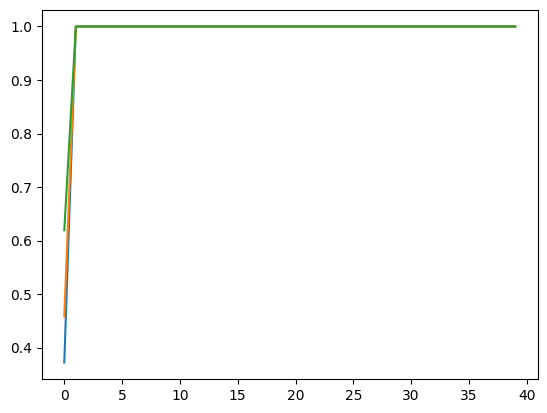

In [179]:
for l in defect_ops_results:
    plt.plot(l[1])

In [180]:
[l[1][-1] for l in defect_ops_results]

[0.999999999999988, 0.9999999999999881, 0.999999999999988]

In [181]:
sites

[6, 7, 8, 9, 10, 11, 12, 13]

In [182]:
left_defect_sites = [6, 7]
right_defect_sites = [12, 13]

In [183]:
left_rdm = (
    psi
    & psi.conj().reindex({f'k{i}': f'b{i}' for i in left_defect_sites})
)
left_rdm = left_rdm.contract()
fuse_map = [
    ('k_left', (f'k{i}' for i in left_defect_sites)),
    ('b_left', (f'b{i}' for i in left_defect_sites))
]
left_rdm.fuse(fuse_map, inplace=True)

right_rdm = (
    psi
    & psi.conj().reindex({f'k{i}': f'b{i}' for i in right_defect_sites})
)
right_rdm = right_rdm.contract()
fuse_map = [
    ('k_right', (f'k{i}' for i in right_defect_sites)),
    ('b_right', (f'b{i}' for i in right_defect_sites))
]
right_rdm.fuse(fuse_map, inplace=True)

Tensor(shape=(4, 4), inds=('k_right', 'b_right'), tags=oset([]))

In [184]:
unitary_pairs = [l[0] for l in defect_ops_results]
left_unitaries, right_unitaries = zip(*unitary_pairs)

In [185]:
left_phases = np.array(get_proj_rep_phases(left_rdm, left_unitaries, 'left', left_defect_sites))

In [186]:
left_phases

array([-0.99354769-0.11341515j,  0.99354769+0.11341515j,
        0.106589  +0.99430317j, -0.106589  -0.99430317j,
        0.933711  -0.35802761j, -0.933711  +0.35802761j])

In [187]:
left_phases[::2]/left_phases[1::2]

array([-1.-6.89412198e-17j, -1.-1.37987283e-17j, -1.-0.00000000e+00j])

So it does work in the full case...! What am I missing?

In [188]:
schmidt_decomp = qtn.tensor_core.tensor_split(
    edms[0],
    left_inds=['k_left', 'b_left'],
    method='svd',
    #cutoff=1e-6,
    cutoff_mode='abs',
    absorb=None,
    renorm=True,
    bond_ind='v'
)

In [190]:
schmidt_decomp.tensors[1]

Tensor(shape=(1,), inds=('v',), tags=oset([]))

In [189]:
np.round(
    schmidt_decomp
    .tensors[0]
    .isel({'v': 0})
    .unfuse(
        {'k_left': ['k1', 'k2'], 'b_left': ['b1', 'b2']},
        shape_map = {'k_left': (2,2), 'b_left': (2,2)}
    ).data,
    3
)

array([[[[-0.498+0.048j, -0.   +0.j   ],
         [-0.   +0.j   ,  0.   -0.j   ]],

        [[ 0.   -0.j   , -0.498+0.048j],
         [-0.   +0.j   ,  0.   +0.j   ]]],


       [[[ 0.   -0.j   ,  0.   -0.j   ],
         [ 0.498-0.048j,  0.   -0.j   ]],

        [[-0.   +0.j   , -0.   -0.j   ],
         [ 0.   -0.j   ,  0.498-0.048j]]]])

# Conclusions
Things aren't working out the way we want. Our projection optimizer is making some assumptions, and we need to calculate multiple projectors simultaneously.
(Fun!)

# Old code

## Test orthogonal projection optimization

In [207]:
dim = 16

In [208]:
M = random_uniform_complex((dim, dim))
state = random_uniform_complex((dim, ))

In [209]:
state = state/np.linalg.norm(state)

In [210]:
ortho_M = project_out_state_from_matrix(M, state)

In [211]:
np.trace(M)

(9.394551579381803+6.985781566398969j)

In [212]:
np.trace(ortho_M) + np.dot(state.conj(), M @ state)

(8.906801415311719+6.634467963401202j)

Close, but not close enough.

In [218]:
dim = 16

def random_uniform_complex(shape):
    return np.random.uniform(size=shape) + 1j*np.random.uniform(size=shape)

M = random_uniform_complex((dim, dim))
state = random_uniform_complex((dim, ))

state = state/np.linalg.norm(state)

def project_out_state_from_matrix(matrix, state):
    # Assume's all are in numpy form.

    I = np.identity(state.shape[0])

    projector = np.outer(state, state.conj())
    orthogonal_projector = I - projector

    out = (
        orthogonal_projector
        @ matrix
        @ orthogonal_projector
    )

    return out


ortho_M = project_out_state_from_matrix(M, state)

np.trace(M), np.trace(ortho_M) + np.vdot(state, M @ state)

((6.601985011684621+7.019769450048232j), (6.60198501168462+7.019769450048232j))